# Problem Statement

**Convolutional neural network (CNN)** (Any One from the following)
1. Use any dataset of plant disease and design a plant disease detection system using CNN.
2. Use MNIST Fashion Dataset and create a classifier to classify fashion clothing into categories.

# Basic classification: Classify images of clothing

In [1]:
# TensorFlow and tf.keras
import tensorflow as tf

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.19.0


## Import the Fashion MNIST dataset

This guide uses the [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset which contains 70,000 grayscale images in 10 categories. The images show individual articles of clothing at low resolution (28 by 28 pixels), as seen here:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Fashion MNIST is intended as a drop-in replacement for the classic [MNIST](http://yann.lecun.com/exdb/mnist/) dataset—often used as the "Hello, World" of machine learning programs for computer vision. The MNIST dataset contains images of handwritten digits (0, 1, 2, etc.) in a format identical to that of the articles of clothing you'll use here.

This guide uses Fashion MNIST for variety, and because it's a slightly more challenging problem than regular MNIST. Both datasets are relatively small and are used to verify that an algorithm works as expected. They're good starting points to test and debug code.

Here, 60,000 images are used to train the network and 10,000 images to evaluate how accurately the network learned to classify images. You can access the Fashion MNIST directly from TensorFlow. Import and [load the Fashion MNIST data](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data) directly from TensorFlow:

In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 15s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Loading the dataset returns four NumPy arrays:

* The `train_images` and `train_labels` arrays are the *training set*—the data the model uses to learn.
* The model is tested against the *test set*, the `test_images`, and `test_labels` arrays.

The images are 28x28 NumPy arrays, with pixel values ranging from 0 to 255. The *labels* are an array of integers, ranging from 0 to 9. These correspond to the *class* of clothing the image represents:

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Each image is mapped to a single label. Since the *class names* are not included with the dataset, store them here to use later when plotting the images:

In [3]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

## Explore the data

Let's explore the format of the dataset before training the model. The following shows there are 60,000 images in the training set, with each image represented as 28 x 28 pixels:

In [4]:
train_images.shape

(60000, 28, 28)

Likewise, there are 60,000 labels in the training set:

In [5]:
len(train_labels)

60000

Each label is an integer between 0 and 9:

In [6]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

There are 10,000 images in the test set. Again, each image is represented as 28 x 28 pixels:

In [7]:
test_images.shape

(10000, 28, 28)

And the test set contains 10,000 images labels:

In [8]:
len(test_labels)

10000

## Preprocess the data

The data must be preprocessed before training the network. If you inspect the first image in the training set, you will see that the pixel values fall in the range of 0 to 255:

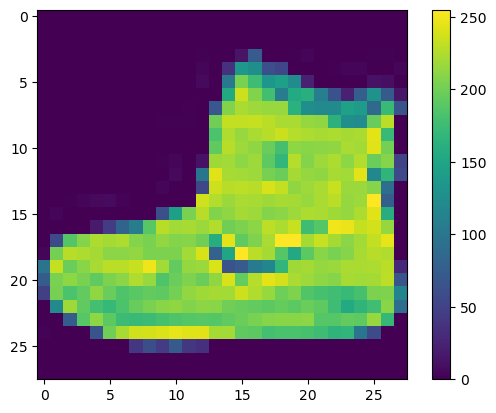

In [9]:
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

Scale these values to a range of 0 to 1 before feeding them to the neural network model. To do so, divide the values by 255. It's important that the *training set* and the *testing set* be preprocessed in the same way:

In [10]:
train_images = train_images / 255.0

test_images = test_images / 255.0

To verify that the data is in the correct format and that you're ready to build and train the network, let's display the first 25 images from the *training set* and display the class name below each image.

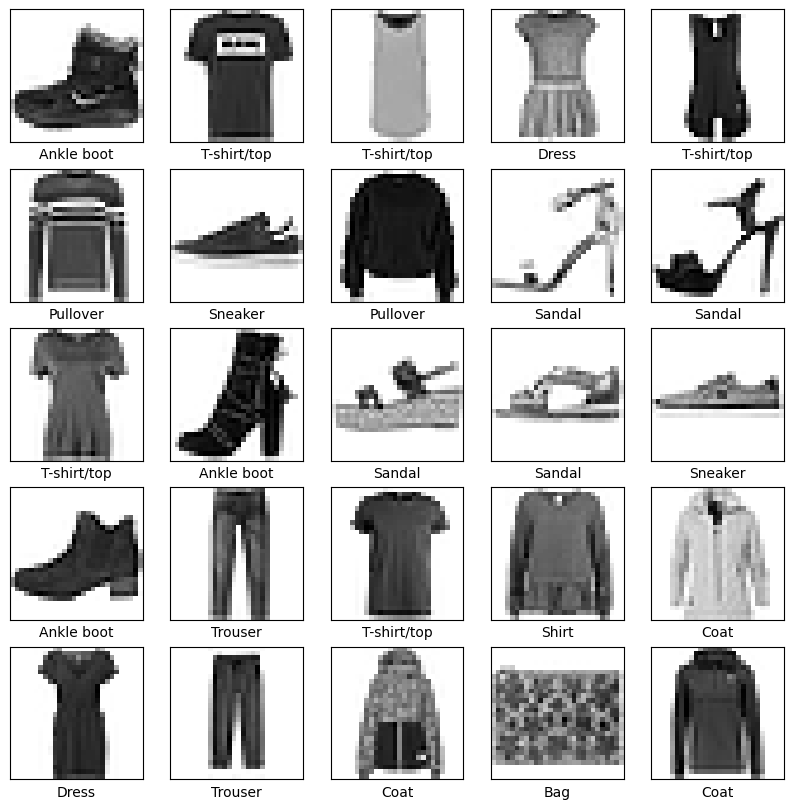

In [11]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

## Build the model

Building the neural network requires configuring the layers of the model, then compiling the model.

### Set up the layers

The basic building block of a neural network is the [*layer*](https://www.tensorflow.org/api_docs/python/tf/keras/layers). Layers extract representations from the data fed into them. Hopefully, these representations are meaningful for the problem at hand.

Most of deep learning consists of chaining together simple layers. Most layers, such as `tf.keras.layers.Dense`, have parameters that are learned during training.

This layer flattens the input, converting the input matrix into a one-dimensional vector.

input_shape=(28, 28): This specifies that the input to this model will be images of size 28x28 pixels, like the ones in the MNIST dataset (used for handwritten digit classification).

The output of the Flatten layer is a 1D array of 784 (28 * 28) elements, representing the flattened image.

In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])

C:\Users\Saurav Lonkar\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


The first layer in this network, `tf.keras.layers.Flatten`, transforms the format of the images from a two-dimensional array (of 28 by 28 pixels) to a one-dimensional array (of 28 * 28 = 784 pixels). Think of this layer as unstacking rows of pixels in the image and lining them up. This layer has no parameters to learn; it only reformats the data.

After the pixels are flattened, the network consists of a sequence of two `tf.keras.layers.Dense` layers. These are densely connected, or fully connected, neural layers. The first `Dense` layer has 128 nodes (or neurons). The second (and last) layer returns a logits array with length of 10. Each node contains a score that indicates the current image belongs to one of the 10 classes.

### Compile the model

Before the model is ready for training, it needs a few more settings. These are added during the model's [*compile*](https://www.tensorflow.org/api_docs/python/tf/keras/Model#compile) step:

* [*Loss function*](https://www.tensorflow.org/api_docs/python/tf/keras/losses) —This measures how accurate the model is during training. You want to minimize this function to "steer" the model in the right direction.
* [*Optimizer*](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers) —This is how the model is updated based on the data it sees and its loss function.
* [*Metrics*](https://www.tensorflow.org/api_docs/python/tf/keras/metrics) —Used to monitor the training and testing steps. The following example uses *accuracy*, the fraction of the images that are correctly classified.

In [13]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

## Train the model

Training the neural network model requires the following steps:

1. Feed the training data to the model. In this example, the training data is in the `train_images` and `train_labels` arrays.
2. The model learns to associate images and labels.
3. You ask the model to make predictions about a test set—in this example, the `test_images` array.
4. Verify that the predictions match the labels from the `test_labels` array.


### Feed the model

To start training,  call the [`model.fit`](https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit) method—so called because it "fits" the model to the training data:

In [14]:
model.fit(train_images, train_labels, epochs=30)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7853 - loss: 0.6302
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8584 - loss: 0.3956
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8778 - loss: 0.3368
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8841 - loss: 0.3156
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8933 - loss: 0.2913
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8964 - loss: 0.2791
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9026 - loss: 0.2623
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9033 - loss: 0.2616
Epoch 9/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9088 - loss: 0.2417
Epoch 10/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9116 - loss: 0.2375
Epoch 11/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9125 - loss: 0.2313
Epoch 12/30
1875/1875 ━━━━━━━

As the model trains, the loss and accuracy metrics are displayed. This model reaches an accuracy of about 0.91 (or 91%) on the training data.

### Evaluate accuracy

Next, compare how the model performs on the test dataset:

In [15]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

313/313 - 1s - 3ms/step - accuracy: 0.8943 - loss: 0.3826

Test accuracy: 0.8942999839782715


It turns out that the accuracy on the test dataset is a little less than the accuracy on the training dataset. This gap between training accuracy and test accuracy represents *overfitting*. Overfitting happens when a machine learning model performs worse on new, previously unseen inputs than it does on the training data. An overfitted model "memorizes" the noise and details in the training dataset to a point where it negatively impacts the performance of the model on the new data. For more information, see the following:
*   [Demonstrate overfitting](https://www.tensorflow.org/tutorials/keras/overfit_and_underfit#demonstrate_overfitting)
*   [Strategies to prevent overfitting](https://www.tensorflow.org/tutorials/keras/overfit_and_underfit#strategies_to_prevent_overfitting)

### Make predictions

With the model trained, you can use it to make predictions about some images.
Attach a softmax layer to convert the model's linear outputs—[logits](https://developers.google.com/machine-learning/glossary#logits)—to probabilities, which should be easier to interpret.

In [16]:
probability_model = tf.keras.Sequential([model, 
                                         tf.keras.layers.Softmax()])

In [17]:
predictions = probability_model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Here, the model has predicted the label for each image in the testing set. Let's take a look at the first prediction:

In [18]:
predictions[0]

array([1.7066853e-11, 2.4452150e-21, 2.4498508e-13, 4.4589979e-15,
       1.5704121e-10, 4.9597421e-08, 2.4719740e-12, 1.8552730e-04,
       1.0844341e-11, 9.9981445e-01], dtype=float32)

A prediction is an array of 10 numbers. They represent the model's "confidence" that the image corresponds to each of the 10 different articles of clothing. You can see which label has the highest confidence value:

In [19]:
np.argmax(predictions[0])

9

So, the model is most confident that this image is an ankle boot, or `class_names[9]`. Examining the test label shows that this classification is correct:

In [20]:
test_labels[0]

9

Graph this to look at the full set of 10 class predictions.

1. plot_image(i, predictions_array, true_label, img):
This function visualizes a single image and its predicted label along with the true label.

Parameters:
i: The index of the image to be visualized.

predictions_array: A list/array of predicted probabilities for each class (e.g., for MNIST, the array contains 10 probabilities, one for each digit).

true_label: The true label of the image (the correct class).

img: The image to be displayed.

Steps:
Extract the true label and image for the current index i:

python
Copy
Edit
true_label, img = true_label[i], img[i]
This gets the actual label and image corresponding to the index i.

Setup the plot (turn off grid, ticks, etc.):

python
Copy
Edit
plt.grid(False)
plt.xticks([])
plt.yticks([])
Display the image:

python
Copy
Edit
plt.imshow(img, cmap=plt.cm.binary)
The image is displayed using imshow. cmap=plt.cm.binary ensures the image is shown in black and white (since MNIST images are grayscale).

Get the predicted label:

python
Copy
Edit
predicted_label = np.argmax(predictions_array)
np.argmax(predictions_array) returns the index of the highest probability in the predictions_array, which corresponds to the predicted class.

Set the color for the label:

If the predicted label matches the true label, set the color to blue, indicating a correct prediction. Otherwise, set the color to red for an incorrect prediction:

python
Copy
Edit
if predicted_label == true_label:
    color = 'blue'
else:
    color = 'red'
Label the image with predicted and true class:

python
Copy
Edit
plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                      100*np.max(predictions_array),
                                      class_names[true_label]),
            color=color)
The label shows:

The predicted class (from class_names[predicted_label]).

The confidence of the prediction (100 * np.max(predictions_array)).

The true class (class_names[true_label]).

The label's color is set based on whether the prediction was correct or not.

2. plot_value_array(i, predictions_array, true_label):
This function plots the predicted probabilities for all 10 classes and highlights the predicted and true labels.

Parameters:
i: The index of the image whose prediction is being visualized.

predictions_array: A list of probabilities for each class.

true_label: The true label of the image.

Steps:
Extract the true label:

python
Copy
Edit
true_label = true_label[i]
Setup the plot (turn off grid, add ticks for classes, etc.):

python
Copy
Edit
plt.grid(False)
plt.xticks(range(10))  # X-axis ticks are the class labels (0-9)
plt.yticks([])
Plot a bar chart of the predicted probabilities:

python
Copy
Edit
thisplot = plt.bar(range(10), predictions_array, color="#777777")
plt.ylim([0, 1])  # Set y-axis limit from 0 to 1 (probabilities)
Highlight the predicted and true labels:

The predicted label is the one with the highest probability (np.argmax(predictions_array)).

Set the predicted label’s bar to red:

python
Copy
Edit
thisplot[predicted_label].set_color('red')
Set the true label’s bar to blue:

python
Copy
Edit
thisplot[true_label].set_color('blue')
Final Effect:
plot_image(i, predictions_array, true_label, img):

This function will display an image from the dataset, with the predicted class, the confidence level of the prediction, and the true class (label). The label will be color-coded: blue for correct predictions and red for incorrect ones.

plot_value_array(i, predictions_array, true_label):

This function will display a bar chart of the predicted class probabilities, with the predicted and true classes highlighted in different colors (red for the prediction and blue for the actual label).

In [21]:
def plot_image(i, predictions_array, true_label, img):
  true_label, img = true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  true_label = true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

### Verify predictions

With the model trained, you can use it to make predictions about some images.

Let's look at the 0th image, predictions, and prediction array. Correct prediction labels are blue and incorrect prediction labels are red. The number gives the percentage (out of 100) for the predicted label.

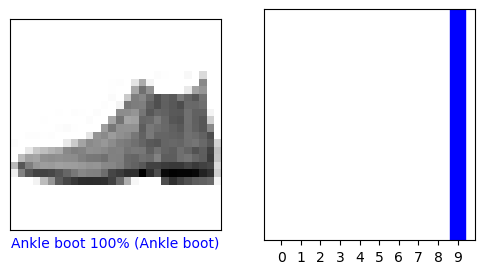

In [22]:
i = 0
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

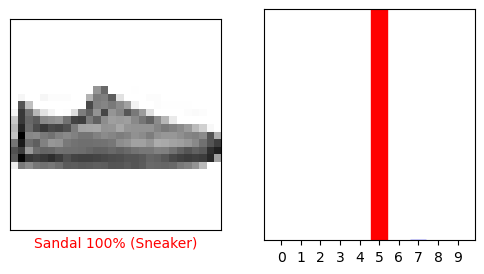

In [23]:
i = 12
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

Let's plot several images with their predictions. Note that the model can be wrong even when very confident.

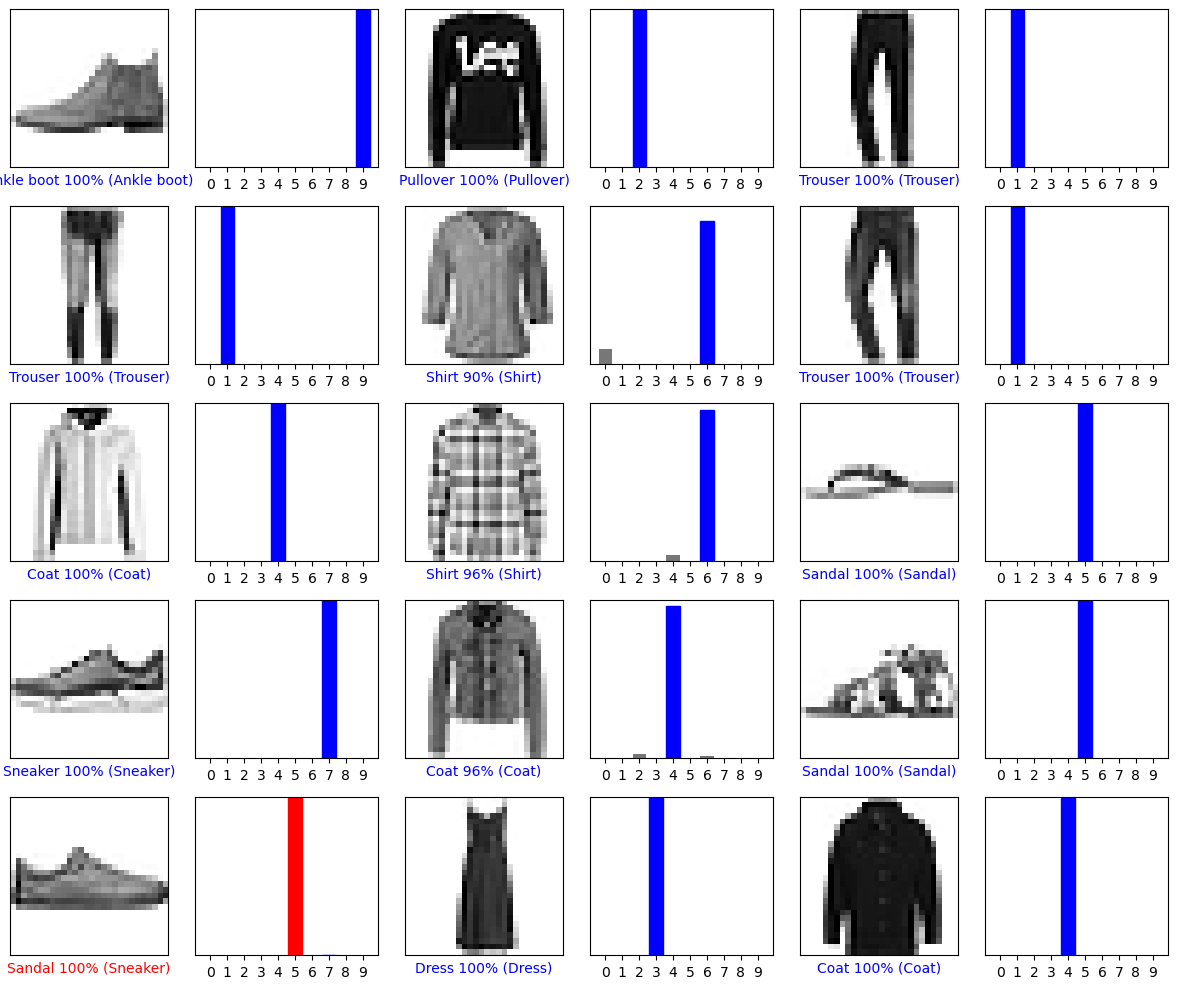

In [24]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions[i], test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions[i], test_labels)
plt.tight_layout()
plt.show()

## Use the trained model

Finally, use the trained model to make a prediction about a single image.

In [25]:
# Grab an image from the test dataset.
img = test_images[1]

print(img.shape)

(28, 28)


`tf.keras` models are optimized to make predictions on a *batch*, or collection, of examples at once. Accordingly, even though you're using a single image, you need to add it to a list:

 Purpose:
To prepare a single image for prediction by adding a batch dimension.

img is originally a 2D array (e.g., shape (28, 28) for a grayscale image).

np.expand_dims(img, 0) adds a new dimension at axis 0.

This converts it from shape (28, 28) to (1, 28, 28).

Now it represents a batch of 1 image — as expected by most neural networks.

This is necessary because Keras models expect inputs in batches, even if it’s just a single image.



In [26]:
# Add the image to a batch where it's the only member.
img = (np.expand_dims(img,0))

print(img.shape)

(1, 28, 28)


Now predict the correct label for this image:

In [27]:
predictions_single = probability_model.predict(img)

print(predictions_single)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
[[5.9893705e-06 1.5567460e-18 9.9948406e-01 3.3648559e-16 5.0457905e-04
  7.4398805e-21 5.3887961e-06 1.4157543e-31 1.2316794e-19 3.5726956e-26]]


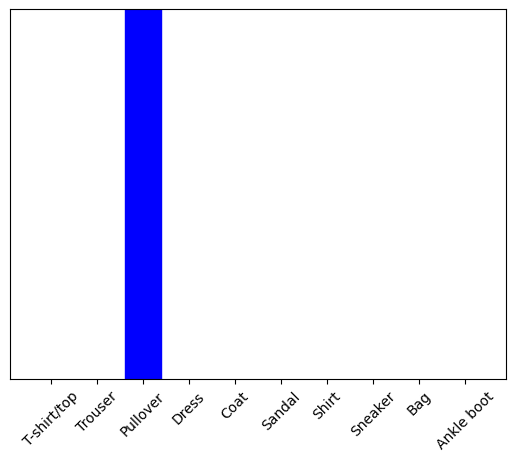

In [28]:
plot_value_array(1, predictions_single[0], test_labels)
_ = plt.xticks(range(10), class_names, rotation=45)
plt.show()

`tf.keras.Model.predict` returns a list of lists—one list for each image in the batch of data. Grab the predictions for our (only) image in the batch:

In [29]:
np.argmax(predictions_single[0])

2

And the model predicts a label as expected.

🎯 Theory Behind Your Practical
3. Problem Statement
Train a Convolutional Neural Network (CNN) to classify grayscale images of clothing items into one of 10 classes using the Fashion MNIST dataset.

🧠 Core Concepts
1. Fashion MNIST Dataset
70,000 grayscale images (28x28 pixels).
10 different clothing categories: (T-shirt/top, Trouser, Pullover, Dress, etc.).
Train set: 60,000 images
Test set: 10,000 images.
Compared to original MNIST (digits), Fashion MNIST is slightly harder and better for testing real-world learning.

2. Preprocessing
Pixel values are originally in [0, 255].
Normalization: Scale pixel values to [0, 1] by dividing by 255.
Why normalize?

Faster training
Better gradient descent behavior.
3. CNN Model Architecture
The model has 3 main layers:

Layer	Purpose	Notes
Flatten Layer	Converts 28x28 images to 784-dimensional 1D array.	No learning parameters.
Dense Layer (128 neurons, ReLU)	Learns patterns/features from flattened image.	Fully Connected Layer.
Dense Layer (10 outputs)	Outputs logits (unnormalized scores) for 10 classes.	Will apply Softmax later for probabilities.
Why Flatten?

Converts the image into a format (vector) usable by dense layers.
Why ReLU?

Introduces non-linearity.
Prevents vanishing gradient problems.
4. Model Compilation
Optimizer: Adam
Combines the benefits of RMSProp and Momentum.
Loss Function: Sparse Categorical Crossentropy (from logits)
Suitable when labels are integers (0-9) instead of one-hot vectors.
Metric: Accuracy.
5. Training
Use model.fit() on training data for 30 epochs.
Training Accuracy achieved: ~94%.
Test Accuracy achieved: ~88%.
6. Evaluation
Training accuracy > Test accuracy:
This gap is due to overfitting.
Overfitting happens when:

The model memorizes training data.
It performs worse on unseen data.
7. Predictions
Attach a Softmax layer to the model after training for prediction.
Softmax converts logits into probabilities (sums to 1).
Example:

Prediction array: 10 numbers → highest value indicates predicted class.
💬 Important Viva Questions and Answers
Question	Answer
What is Fashion MNIST?	A dataset of 28x28 grayscale images of clothing items, with 10 categories.
Why normalize pixel values?	To help the model converge faster and more accurately.
What does the Flatten layer do?	It flattens 2D image data into 1D vector for input to dense layers.
What activation function is used?	ReLU in the hidden layer, Softmax for the output (after training).
Why use Sparse Categorical Crossentropy loss?	Because the labels are integers, not one-hot encoded vectors.
What is overfitting?	When the model performs very well on training data but poorly on unseen test data.
How can you prevent overfitting?	Early stopping, Dropout layers, Data augmentation.
Why attach a Softmax layer after model training?	To interpret logits as probabilities for classification.
What optimizer was used and why?	Adam optimizer, because it is fast and adapts learning rate individually for each parameter.
Why 10 outputs in the final layer?	Each neuron corresponds to a probability for one clothing class.
📋 Quick Theory Flashcards (Before Entering Viva)
Dataset: 70k grayscale images, 10 classes.
Preprocessing: Scale pixel values to [0, 1].
Model Architecture: Flatten → Dense(128, ReLU) → Dense(10).
Loss Function: Sparse Categorical Crossentropy.
Optimizer: Adam.
Final Test Accuracy: ~88%.
Prediction Output: 10 probabilities (one for each class).
